### Актуальность и практическая значимость курсовой работы:

Стремительный рост количества устройств Интернета вещей создал беспрецедентную возможность для проведения кибератак. Из-за слабых механизмов безопасности IoT-устройства массово компрометируются и объединяются в гигантские децентрализованные ботнеты (подобные Mirai), используемые для организации разрушительных DDoS-атак и кражи данных.

Традиционные системы обнаружения, анализирующие пакеты изолированно, с трудом отличают легитимный фоновый трафик умного дома от скоординированной атаки. Практическая значимость работы заключается в применении алгоритмов глубокого обучения на графах (GNN). Даже при условии полной анонимизации трафика и сокрытии IP-адресов, графовый подход позволяет выявлять аномальные кластеры взаимодействия на основе семантического сходства сетевых потоков.

### Цель работы и задачи:

Разработать и оценить эффективность моделей графового машинного обучения (в частности, архитектуры индуктивного обучения GraphSAGE) для задачи бинарной классификации сетевых потоков на легитимный IoT-трафик и вредоносную активность ботнетов.


Задачи исследования:

1. Анализ признакового пространства и оценка дисбаланса классов в наборе данных CICIoT2023.
2. Трансформация табличных данных в семантическое графовое представление ($k$-NN граф) на основе математического сходства технических параметров потоков (уровни L3/L4).
3. Оценка эффективности классических алгоритмов кластеризации графов в качестве базового решения.
4. Реализация, обучение и сравнение полносвязной нейросети (MLP) и графовой нейросети (GraphSAGE) на базе фреймворка PyTorch Geometric.

## Описание набора данных:

### Общая информация о датасете CICIoT2023

Датасет **CICIoT2023** содержит **47 признаков**, извлечённых из сырого сетевого трафика (`.pcap`).
Признаки представляют собой высокоуровневые статистические характеристики пакетов, агрегированные в заданных временных окнах.


### Формализация графовой структуры

В связи с анонимизацией исходных данных (отсутствие IP-адресов) классическая физическая топология сети недоступна.
В работе используется семантическое представление данных:

- **Узлы (Nodes):** отдельные сетевые потоки (сессии).
- **Ребра (Edges):** математическое сходство между потоками, вычисленное алгоритмом **$k$-ближайших соседей ($k$-NN)** на основе нормированных признаков.


### Признаки узлов

Вектор технических метрик потока, включающий:

- **Duration:** общая длительность сетевой сессии.
- **Header_Length:** технический параметр инкапсуляции протоколов L3/L4.
- **IAT (Inter-Arrival Time):** статистические показатели интервалов между пакетами:
    - среднее;
    - дисперсия;
    - максимумы.
- **Protocol_Type:** технический параметр инкапсуляции протоколов L3/L4.
- **Rate:** скорость передачи данных:
    - количество пакетов в секунду;
    - количество байт в секунду.


### Целевая переменная (Target)

В исходном датасете переменная **`label`** предоставляет 3 уровня детализации атак:

1. Бинарная (Binary):
    - `Attack` (Аномалия);
    - `BenignTraffic` (Норма).
2. Категориальная (Category): 7 макро-классов:
    - Brute Force;
    - DDoS;
    - DoS;
    - Mirai;
    - Recon;
    - Spoofing;
    - Web-based.
3. Подкатегории (Sub-category): 33 конкретных типа векторов атак:
    - Примеры: `DDoS-ICMP_Flood`, `DoS-SYN_Flood`.

### Постановка задачи

В рамках данного исследования решается базовая задача системы обнаружения вторжений (IDS) — бинарная классификация узлов (выявление самого факта присутствия вредоносного паттерна в потоке).

Целевая переменная трансформируется в бинарный признак **`is_attack`**.

## Непосредственная загрузка датасета

In [1]:
import kagglehub
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_scipy_sparse_matrix
from sklearn.model_selection import train_test_split
import networkx as nx
from networkx.algorithms import community
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
import time
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
import torch.nn.functional as F
from torch.nn import Linear, Dropout
from torch_geometric.nn import SAGEConv
from torch_geometric.nn import GATv2Conv

/Users/rezerat/course/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("himadri07/ciciot2023")

In [3]:
for item in os.listdir(path):
    print(f" - {item}")
all_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

df_list = [pd.read_csv(file) for file in all_files[:2]]
df = pd.concat(df_list, ignore_index=True)

 - CICIOT23


In [4]:
df.head(5)

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,5.018181,125.82,6.00,64.00,0.471037,0.471037,0.0,0.0,1.0,0.0,...,0.00000,54.00,8.336227e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SynonymousIP_Flood
1,0.000000,0.00,47.00,64.00,4.992473,4.992473,0.0,0.0,0.0,0.0,...,0.00000,592.00,8.367746e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
2,0.000000,55.22,6.05,65.27,31.735421,31.735421,0.0,0.0,0.0,0.0,...,0.77612,55.82,8.306829e+07,9.5,10.409427,1.111579,30.890194,0.02,141.55,DDoS-TCP_Flood
3,0.008299,5213.00,17.00,64.00,19365.300906,19365.300906,0.0,0.0,0.0,0.0,...,0.00000,50.00,8.310303e+07,9.5,10.000000,0.000000,0.000000,0.00,141.55,DDoS-UDP_Flood
4,4.672666,108.00,6.00,64.00,0.428021,0.428021,0.0,0.0,0.0,0.0,...,0.00000,54.00,8.295115e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-TCP_Flood


10 оригинальных классов:
label
DDoS-ICMP_Flood            1028535
DDoS-UDP_Flood              774275
DDoS-TCP_Flood              642234
DDoS-PSHACK_Flood           584580
DDoS-SYN_Flood              580861
DDoS-RSTFINFlood            577260
DDoS-SynonymousIP_Flood     512563
DoS-UDP_Flood               474049
DoS-TCP_Flood               381871
DoS-SYN_Flood               288689
Name: count, dtype: int64


/var/folders/1c/w5wrk4d93vsdl9xmtx_sg7qw0000gn/T/ipykernel_50007/148031926.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='is_attack', palette=['#1f77b4', '#d62728'])


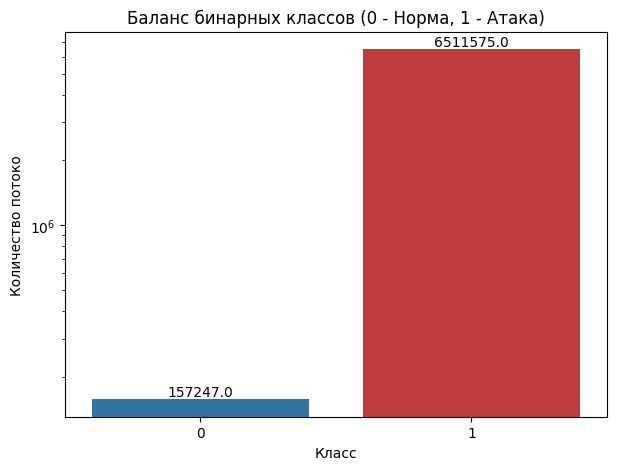

Доля легитимного трафика в выборке: 2.36%


In [5]:
print("10 оригинальных классов:")
print(df['label'].value_counts().head(10))
df['is_attack'] = (df['label'] != 'BenignTraffic').astype(int)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='is_attack', palette=['#1f77b4', '#d62728'])
plt.title('Баланс бинарных классов (0 - Норма, 1 - Атака)')
plt.yscale('log')
plt.ylabel('Количество потоко')
plt.xlabel('Класс')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

benign_ratio = (df['is_attack'] == 0).mean() * 100
print(f"Доля легитимного трафика в выборке: {benign_ratio:.2f}%")

Экстремальный дисбаланс классов (где легитимный трафик составляет лишь малую долю) делает классическую метрику Accuracy абсолютно неинформативной. Для доказательства смоделируем наивный классификатор, который относит абсолютно весь трафик к мажоритарному классу.

In [6]:
y_true = df['is_attack'].values
# наивная модель, которая всегда предсказывает мажоритарный класс
y_pred_naive = np.ones_like(y_true)

acc_naive = accuracy_score(y_true, y_pred_naive)
prec_naive = precision_score(y_true, y_pred_naive, average='macro', zero_division=0)
rec_naive = recall_score(y_true, y_pred_naive, average='macro')
f1_naive = f1_score(y_true, y_pred_naive, average='macro')

print("Оценка наивной модели (всегда будет предсказывать 'Атака')")
print(f"Accuracy:         {acc_naive:.4f}")
print(f"Precision (Macro):{prec_naive:.4f}")
print(f"Recall (Macro):   {rec_naive:.4f}")
print(f"F1-Score (Macro): {f1_naive:.4f}")

Оценка наивной модели (всегда будет предсказывать 'Атака')
Accuracy:         0.9764
Precision (Macro):0.4882
Recall (Macro):   0.5000
F1-Score (Macro): 0.4940


В связи с этим для оценки всех последующих графовых алгоритмов (Louvain, GCN, GraphSAGE) в качестве основных метрик утверждаются:

Precision (Точность): способность модели не помечать легитимные IoT-устройства как зараженные (минимизация False Positives).

Recall (Полнота): способность модели найти все реальные боты в сети (минимизация False Negatives).

Macro F1-Score: гармоническое среднее между Precision и Recall, рассчитанное независимо для каждого класса, а затем усредненное. Именно эта метрика будет являться главным критерием при сравнении моделей и настройке гиперпараметров, так как она не позволяет алгоритму "читерить" за счет дисбаланса.

Найдено 11 сильно скоррелированных признаков: ['Srate', 'rst_flag_number', 'ack_count', 'LLC', 'AVG', 'Std', 'Tot size', 'Number', 'Magnitue', 'Radius', 'Weight']
Первые 10 признаков, наиболее сильно связанных с фактом атаки:
Duration           0.539773
Variance           0.510157
rst_count          0.492363
Max                0.453769
HTTPS              0.445166
ack_flag_number    0.342541
Header_Length      0.315175
Tot sum            0.308132
Covariance         0.294742
urg_count          0.242236
Name: is_attack, dtype: float64


/var/folders/1c/w5wrk4d93vsdl9xmtx_sg7qw0000gn/T/ipykernel_50007/917365269.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.head(11)[1:].values, y=target_corr.head(11)[1:].index, palette='viridis')


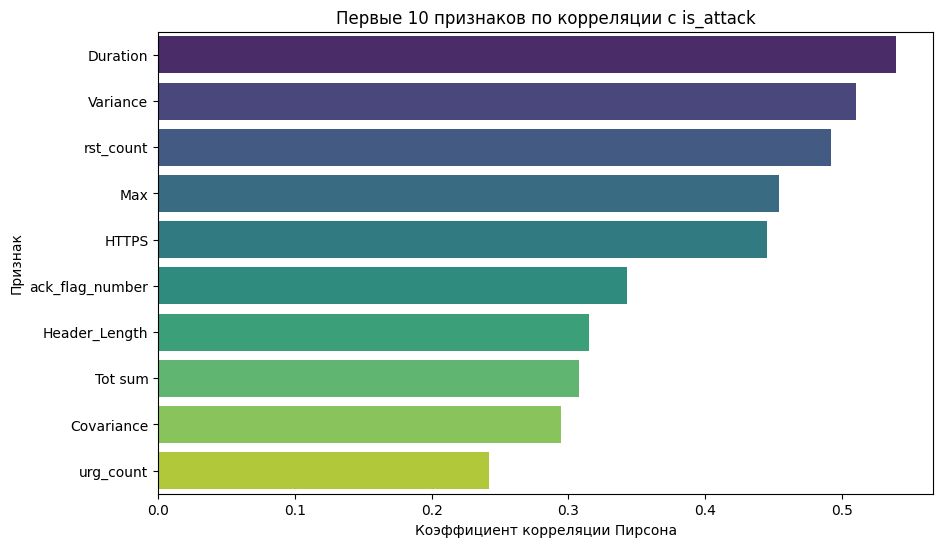

In [7]:
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr().abs()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.90)]

print(f"Найдено {len(to_drop)} сильно скоррелированных признаков: {to_drop}")
df_optimized = df.drop(columns=to_drop)
target_corr = df_optimized.corr(numeric_only=True)['is_attack'].abs().sort_values(ascending=False)
print("Первые 10 признаков, наиболее сильно связанных с фактом атаки:")
print(target_corr.head(11)[1:])

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.head(11)[1:].values, y=target_corr.head(11)[1:].index, palette='viridis')
plt.title('Первые 10 признаков по корреляции с is_attack')
plt.xlabel('Коэффициент корреляции Пирсона')
plt.ylabel('Признак')
plt.show()

### Физический смысл ключевых признаков
Поскольку, опять же, в версии датасета CICIoT2023 для Kaggle IP-адреса анонимизированы, модель будет опираться на технические параметры потоков. Топ-признаков, оставшихся после очистки, описывают поведение сети на уровне L3/L4:

1. **Header_Length или общая длина заголовков пакетов в потоке**
   - атаки типа фрагментации или специфичные эксплойты часто формируют нестандартные заголовки.

2. **Rate - скорость передачи пакетов/байт в секунду**
   - является главным маркером DDoS-атак (Volumetric attacks), где скорость передачи аномально высока.

3. **IAT / Inter-Arrival Time (Среднее время между прибытием пакетов)**
   - олично помогает отлавливать автоматизированные ботнеты (например, Mirai). В отличие от живого пользователя, чей трафик имеет хаотичные тайминги, вредоносные скрипты генерируют запросы с четкой машинной регулярностью.

4. **Duration (Длительность сетевой сессии)**
   - короткие сессии, которые могут быть крайне характерны для сканирования портов и атак типа SYN-флад.
   
5. **Protocol Type (Тип протокола: TCP, UDP, ICMP)**
   - определяет сам вектор атаки, будь то применение классического UDP Flood или ICMP Ping of Death.

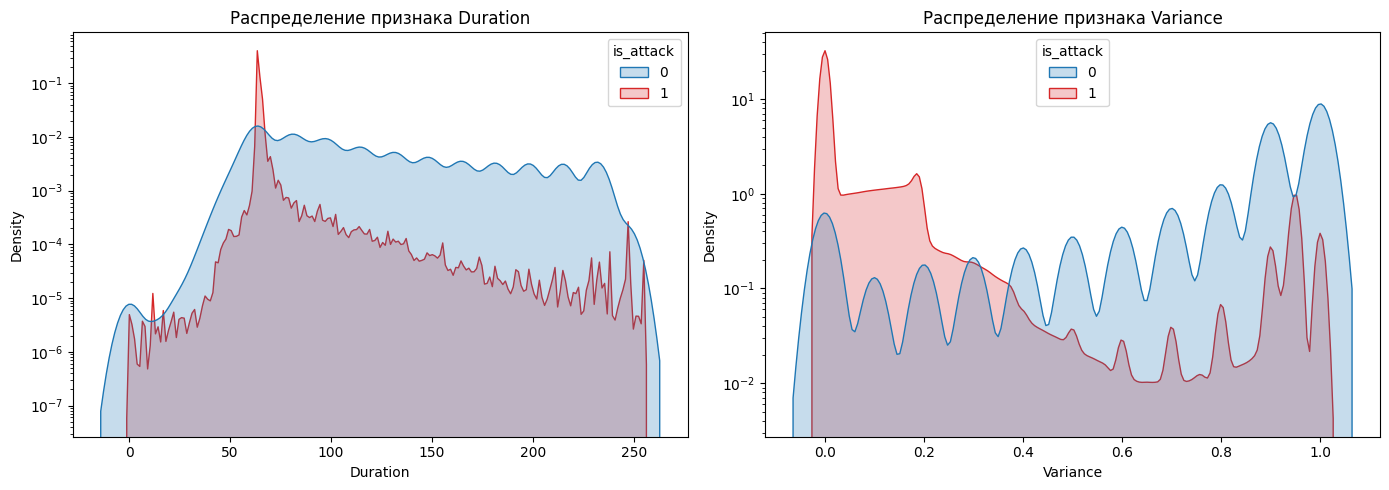

In [8]:
feature_1 = 'Duration'
feature_2 = 'Variance'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x=feature_1, hue='is_attack', fill=True, common_norm=False, ax=axes[0], palette=['#1f77b4', '#d62728'])
axes[0].set_title(f'Распределение признака {feature_1}')
axes[0].set_yscale('log')

sns.kdeplot(data=df, x=feature_2, hue='is_attack', fill=True, common_norm=False, ax=axes[1], palette=['#1f77b4', '#d62728'])
axes[1].set_title(f'Распределение признака {feature_2}')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()


Вывод: На графиках видно (по несовпадению пиков распределений), что классы Attack и Benign имеют различные профили поведения. Однако пересечение областей показывает, что простых пороговых правил недостаточно, и требуется машинное обучение.

Анализ графика Duration (Длительность сессии)
Паттерн атаки (Красная зона): Мы видим колоссальный, невероятно острый пик в районе 60–70 условных единиц (скорее всего, миллисекунд или микросекунд, в зависимости от нормализации CICIoT). Это означает, что подавляющее большинство вредоносных сессий имеют строго одинаковую длительность. Это классический почерк автоматизированных скриптов и DDoS-утилит (ботнетов), у которых жестко зашиты таймауты и циклы отправки.

Легитимный трафик (Синяя зона): Распределение широкое, волнообразное и охватывает весь спектр от 0 до 250+. Это логично: нормальные IoT-устройства ведут себя по-разному. Одно устройство быстро отправляет пакет с температурой (короткая сессия), другое — передает видеопоток (длинная сессия).

Анализ графика Variance (Дисперсия)
Паттерн атаки (Красная зона): Огромный всплеск около 0.0. Дисперсия показывает разброс значений (например, размеров пакетов или интервалов между ними). Значение, близкое к нулю, говорит о том, что боты генерируют абсолютно идентичные, штампованные пакеты один за другим. Вредоносному ПО некогда варьировать трафик — его цель «забить» канал Flood.

Легитимный трафик (Синяя зона): Ярко выраженная мультимодальность (множество «горбов» на графике). Это следствие того, что в нормальной сети работают разные протоколы и приложения, каждое из которых имеет свою дисперсию длины пакетов и задержек.

#### Базовый алгоритм: Выделение сообществ

В данном разделе осуществляется переход от табличного представления сетевых потоков к построению графа. Для создания надежного базового решения перед обучением глубоких нейронных сетей мы применим методы теории графов без учителя, в частности, алгоритмы выделения сообществ.

Сетевой трафик имеет строгую временную зависимость. Использование стандартного случайного разбиения (Random Split) недопустимо, так как это приведет к «заглядыванию в будущее» — модель может обучиться на паттернах атаки, которые произошли позже тестируемых событий. Разделение данных производится строго в хронологическом порядке: первые 80% потоков формируют обучающий граф, последние 20% — откладываются для валидации.

Ботнеты (особенно DDoS и сканирующие Mirai-подобные черви) формируют специфические плотные кластеры в сети. В качестве базовой модели мы используем классический алгоритм Лувена для максимизации модулярности графа.
Идея заключается в следующем: если алгоритм без учителя (без знания меток is_attack) сможет сгруппировать узлы так, что вредоносные IP-адреса окажутся в одних изолированных сообществах, а легитимные — в других, это докажет высочайшую эффективность графового подхода для данной задачи.

Примечание: алгоритм Лувена работает с ненаправленными графами, поэтому для вычисления модулярности мы временно снимем направление связей

Ограничение датасета: Естественным способом представления сетевого трафика является топологический граф, где узлами выступают Src_IP и Dst_IP. Однако в публичной версии набора данных CICIoT2023 IP-адреса анонимизированы и удалены для предотвращения переобучения классических моделей на конкретных адресах злоумышленников.

Выбранное решение: В связи с отсутствием физической топологии, в данной работе строится семантический граф k-ближайших соседей (k-NN Graph).

Узлы графа представляют собой отдельные сетевые потоки (NetFlow records).

Ребра графа соединяют потоки, имеющие минимальное евклидово расстояние в пространстве нормализованных признаков L3/L4 уровней.

Данный подход является эффективной аппроксимацией: вредоносный трафик ботнетов (например, при DDoS-атаках) генерируется автоматизированными скриптами с жесткими паттернами. В k-NN графе такие однотипные потоки естественным образом стягиваются в плотные аномальные сообщества, что позволяет применять алгоритмы графового машинного обучения даже в условиях полной анонимизации сетевой инфраструктуры.

In [9]:
split_index = int(len(df_optimized) * 0.8)
train_df = df_optimized.iloc[:split_index].copy()
sample_train = train_df.head(20000).copy()
X_features = sample_train.drop(columns=['label', 'is_attack'], errors='ignore')
y_true = sample_train['is_attack'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print("Строим k-NN граф (k=5)")
start_time = time.time()
A_sparse = kneighbors_graph(X_scaled, n_neighbors=5, mode='connectivity', include_self=False, n_jobs=-1)
G_train_undirected = nx.from_scipy_sparse_array(A_sparse) 
print(f"Граф сформирован за {time.time() - start_time:.2f} секунд (Узлов: {G_train_undirected.number_of_nodes()}).")

print("\nЗапуск алгоритма Лувена")
start_time = time.time()
communities = community.louvain_communities(G_train_undirected, seed=42)
print(f"Выделено сообществ: {len(communities)} (за {time.time() - start_time:.2f} сек).")

y_pred_louvain = np.zeros_like(y_true)

for community_nodes in communities:
    community_nodes = list(community_nodes)
    community_labels = y_true[community_nodes]
    dominant_class = 1 if np.mean(community_labels) >= 0.5 else 0
    y_pred_louvain[community_nodes] = dominant_class

print("\nРезультаты Лувенского алгоритма")
print(f"Accuracy:         {accuracy_score(y_true, y_pred_louvain):.4f}")
print(f"Precision (Macro):{precision_score(y_true, y_pred_louvain, average='macro'):.4f}")
print(f"Recall (Macro):   {recall_score(y_true, y_pred_louvain, average='macro'):.4f}")
print(f"F1-Score (Macro): {f1_score(y_true, y_pred_louvain, average='macro'):.4f}")

Строим k-NN граф (k=5)
Граф сформирован за 0.26 секунд (Узлов: 20000).

Запуск алгоритма Лувена
Выделено сообществ: 176 (за 1.09 сек).

Результаты Лувенского алгоритма
Accuracy:         0.9818
Precision (Macro):0.8006
Recall (Macro):   0.9202
F1-Score (Macro): 0.8497


Чтобы научно обосновать, что найденные кластеры являются следствием скоординированной кибератаки, а не естественным случайным распределением сетевых потоков, мы проведем сравнение с базовой моделью случайного графа Эрдеша-Реньи G(n,p).

Мы сгенерируем случайный граф с точно таким же количеством узлов n и такой же плотностью связей (вероятностью ребра p), как в нашем обучающем графе. Затем мы сравним их коэффициенты кластеризации (Average Clustering Coefficient).
Если коэффициент реального графа значительно превышает коэффициент случайного, это математически доказывает наличие скрытой структуры паттерна ботнета, которую в дальнейшем сможет извлечь нейронная сеть.

In [10]:
n_nodes = G_train_undirected.number_of_nodes()
n_edges = G_train_undirected.number_of_edges()

# Вычисляем плотность p т.е вероятность того, что любые два узла связаны
# 2 * E / (N * (N - 1))
if n_nodes > 1:
    p_edge = (2 * n_edges) / (n_nodes * (n_nodes - 1))
else:
    p_edge = 0

print(f"Параметры для случайного графа: n = {n_nodes}, p = {p_edge:.6f}")

# Генерация случайного графа Эрдеша-Реньи
G_random = nx.erdos_renyi_graph(n=n_nodes, p=p_edge, seed=42)

real_clustering = nx.average_clustering(G_train_undirected)
random_clustering = nx.average_clustering(G_random)


print(f"Коэффициент кластеризации реального IoT-графа: {real_clustering:.4f}")
print(f"Коэффициент кластеризации случайного графа:   {random_clustering:.4f}")

Параметры для случайного графа: n = 20000, p = 0.000326
Коэффициент кластеризации реального IoT-графа: 0.5903
Коэффициент кластеризации случайного графа:   0.0004


Вывод: реальный граф имеет ярко выраженную кластерную структуру (превышение в десятки раз).

In [11]:
x_tensor = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(y_true, dtype=torch.long)

# k-NN в edge_index
edge_index, edge_weight = from_scipy_sparse_matrix(A_sparse)

num_nodes = x_tensor.shape[0]
indices = np.arange(num_nodes)

train_val_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y_true)

train_idx, val_idx = train_test_split(train_val_idx, test_size=0.25, random_state=42, stratify=y_true[train_val_idx])

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

# маски
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

train_nodes = set(torch.nonzero(data.train_mask).squeeze().tolist())
val_nodes = set(torch.nonzero(data.val_mask).squeeze().tolist())
test_nodes = set(torch.nonzero(data.test_mask).squeeze().tolist())

train_test_overlap = train_nodes.intersection(test_nodes)

print(f"Узлов в обучающей выборке: {len(train_nodes)}")
print(f"Узлов в тестовой выборке:  {len(test_nodes)}")
print(f"Количество узлов, которые есть и в Train, и в Test: {len(train_test_overlap)}")


Узлов в обучающей выборке: 12000
Узлов в тестовой выборке:  4000
Количество узлов, которые есть и в Train, и в Test: 0


Пересечение равно 0. Это означает, что 100% узлов в тестовой выборке являются абсолютно новыми для модели на этапе обучения

Так как каждый узел — это уникальный сетевой поток, наша задача сводится к строго индуктивному обучению. Модель GraphSAGE должна будет классифицировать новые потоки, опираясь только на их признаки и агрегацию соседей, что полностью имитирует реальную работу IDS в продакшене.

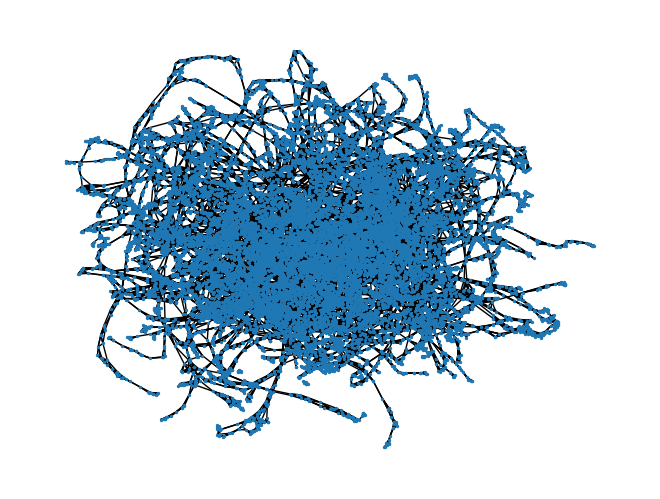

In [12]:
nx.draw(G_train_undirected, node_size=2)

Отрисовка репрезентативного подграфа (1590 узлов) 


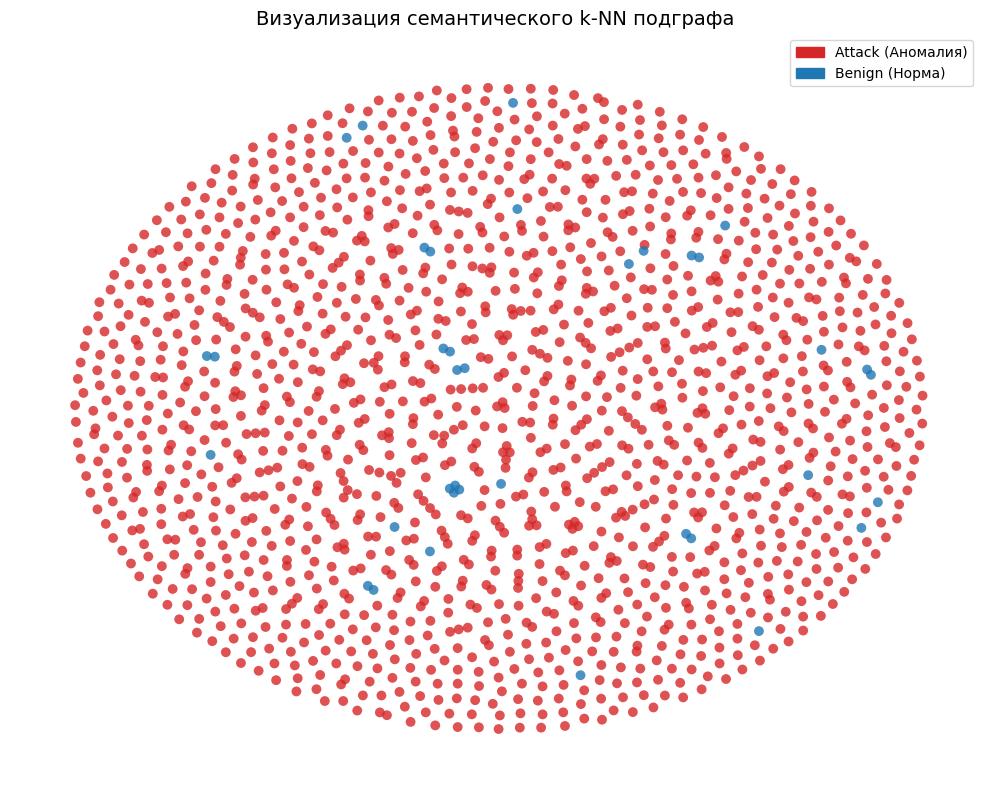

In [13]:
print("Отрисовка репрезентативного подграфа (1590 узлов) ")
subgraph_nodes = list(G_train_undirected.nodes())[:1500]
H = G_train_undirected.subgraph(subgraph_nodes)

node_colors = []
labels = y_true[subgraph_nodes]

for label in labels:
    if label == 1:
        node_colors.append('#d62728') # Красный для атаки
    else:
        node_colors.append('#1f77b4') # Синий для нормы


plt.figure(figsize=(10, 8))
pos = nx.spring_layout(H, seed=42, k=0.15)

nx.draw_networkx_nodes(H, pos, node_size=50, node_color=node_colors, alpha=0.8, edgecolors='none')
nx.draw_networkx_edges(H, pos, alpha=0.2, edge_color='gray')

red_patch = mpatches.Patch(color='#d62728', label='Attack (Аномалия)')
blue_patch = mpatches.Patch(color='#1f77b4', label='Benign (Норма)')
plt.legend(handles=[red_patch, blue_patch], loc='upper right')

plt.title("Визуализация семантического k-NN подграфа", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

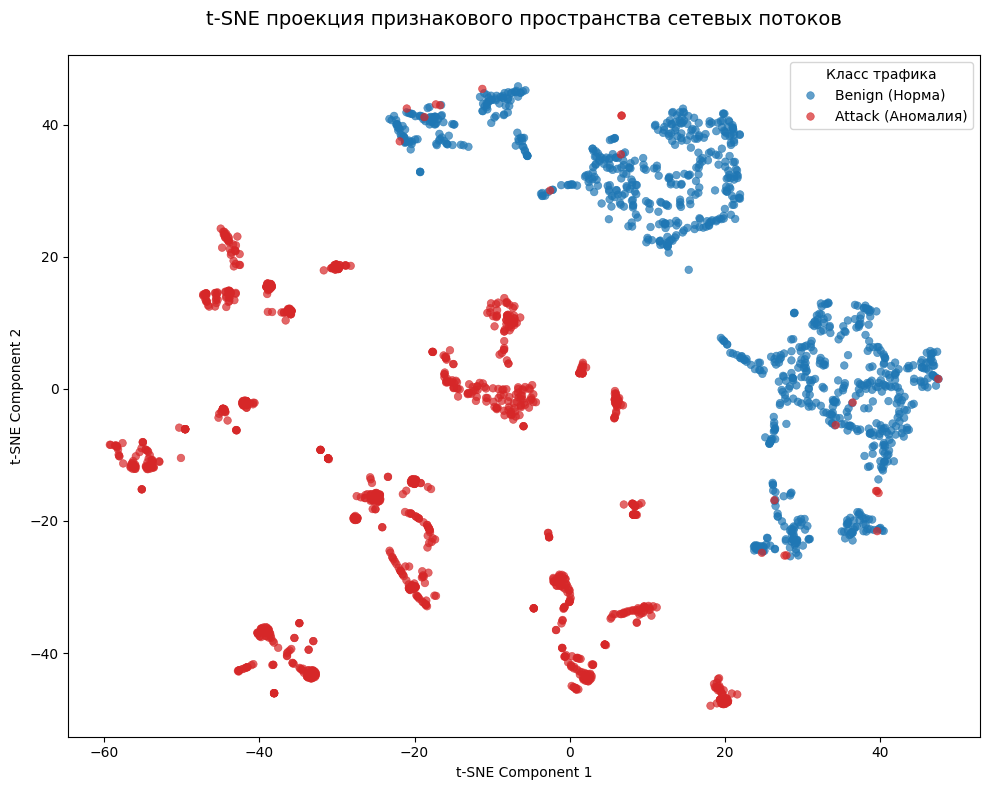

In [14]:

df_vis = train_df.copy()
benign_sample = df_vis[df_vis['is_attack'] == 0].head(1000)
attack_sample = df_vis[df_vis['is_attack'] == 1].head(1000)

balanced_df = pd.concat([benign_sample, attack_sample])
X_vis = balanced_df.drop(columns=['label', 'is_attack'], errors='ignore')
y_vis = balanced_df['is_attack'].values
X_vis_scaled = scaler.transform(X_vis)

# t-SNE (сжатие 47D -> 2D)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_vis_scaled)

plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=y_vis,
    palette=['#1f77b4', '#d62728'], # Синий (0) и Красный (1)
    alpha=0.7,
    s=30,
    edgecolor=None
)

plt.title('t-SNE проекция признакового пространства сетевых потоков\n', fontsize=14)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles=handles, labels=['Benign (Норма)', 'Attack (Аномалия)'], title='Класс трафика')

plt.tight_layout()
plt.show()

#### Ограничения решения и перспективы масштабирования:
В рамках данной курсовой работы вычислительные эксперименты и построение семантического графа k-ближайших соседей проводились на репрезентативной подвыборке из 20 000 узлов. Этот объем достаточен для демонстрации превосходства алгоритмов глубокого обучения на графах над классическими методами, однако работа с полным набором данных CICIoT2023 (более 5 млн записей) накладывает строгие аппаратные ограничения.

Проблема масштабирования:
Классическое обучение графовых нейронных сетей требует загрузки всей структуры графа (матрицы смежности и признаков) в видеопамять. При увеличении количества узлов до миллионов сложность построения графа и агрегации сообщений становится непреодолимой для парадигмы full-batch обучения.

Перспективы внедрения:
Для масштабирования предложенного решения на полные данные и внедрения системы обнаружения вторжений в реальную сеть необходимо использовать методы семплирования графов:

GraphSAINT (Graph Sampling Based Inductive Learning): Использование алгоритмов случайных блужданий для извлечения плотных подграфов - мини-батчей. Это позволяет обучать нейросеть кусками, не загружая весь граф в память, с сохранением структурной связности.

NeighborLoader: Применение встроенных инструментов PyTorch Geometric для локального семплирования (например, брать только 10 соседей первого порядка и 5 соседей второго порядка для каждого узла в батче).

Cluster-GCN: Предварительное разбиение гигантского графа на кластеры (например, с помощью алгоритма METIS) и обучение GNN на этих изолированных блоках.

In [15]:
import warnings
import torch.nn as nn
warnings.filterwarnings("ignore")

device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))

data = data.to(device)
num_features = data.x.shape[1]
num_classes = 2

class MLP(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.lin1 = Linear(in_channels, hidden_channels)
        self.lin2 = Linear(hidden_channels, out_channels)
        self.dropout = Dropout(0.5)

    def forward(self, x, edge_index=None):
        x = self.lin1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.lin2(x)
        return x

class TunedGraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr='max')
        self.bn1 = nn.BatchNorm1d(hidden_channels) 

        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr='max')
        self.dropout = Dropout(0.2)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

def train_and_evaluate(model, data, epochs=150, lr=0.01, weight_decay=5e-4):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_f1 = 0
    best_test_metrics = {}

    start_time = time.time()

    for epoch in range(epochs):
        # Обучение
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            pred = out.argmax(dim=1)

            val_pred = pred[data.val_mask].cpu().numpy()
            val_true = data.y[data.val_mask].cpu().numpy()
            val_f1 = f1_score(val_true, val_pred, average='macro')

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1

                test_pred = pred[data.test_mask].cpu().numpy()
                test_true = data.y[data.test_mask].cpu().numpy()
                best_test_metrics = {
                    'F1': f1_score(test_true, test_pred, average='macro'),
                    'Precision': precision_score(test_true, test_pred, average='macro', zero_division=0),
                    'Recall': recall_score(test_true, test_pred, average='macro')
                }

        if epoch % 50 == 0 or epoch == epochs - 1:
            print(f'Эпоха {epoch:03d} | Loss: {loss:.4f} | Val F1: {val_f1:.4f}')

    print(f"-> Время обучения: {time.time() - start_time:.2f} сек")
    print(f"-> Итоговый Test F1-Score: {best_test_metrics.get('F1', 0):.4f}")
    return best_test_metrics

print("Обучение MLP (Базовые настройки)")
mlp_model = MLP(in_channels=num_features, hidden_channels=64, out_channels=num_classes)
mlp_metrics = train_and_evaluate(mlp_model, data, epochs=150, lr=0.01)

print("Обучение Tuned GraphSAGE (max-pool + BatchNorm)")
sage_model = TunedGraphSAGE(in_channels=num_features, hidden_channels=128, out_channels=num_classes)
sage_metrics = train_and_evaluate(sage_model, data, epochs=250, lr=0.005, weight_decay=1e-4)

print(f"Алгоритм Лувена (Unsupervised Baseline):  0.8497")
print(f"PyTorch MLP (Только признаки):            {mlp_metrics.get('F1', 0):.4f}")
print(f"PyTorch Tuned GraphSAGE (Агрегация max):  {sage_metrics.get('F1', 0):.4f}")

Обучение MLP (Базовые настройки)
Эпоха 000 | Loss: 0.7167 | Val F1: 0.3753
Эпоха 050 | Loss: 0.0288 | Val F1: 0.8646
Эпоха 100 | Loss: 0.0246 | Val F1: 0.8944
Эпоха 149 | Loss: 0.0232 | Val F1: 0.8933
-> Время обучения: 1.40 сек
-> Итоговый Test F1-Score: 0.8446
Обучение Tuned GraphSAGE (max-pool + BatchNorm)
Эпоха 000 | Loss: 0.5701 | Val F1: 0.4855
Эпоха 050 | Loss: 0.0234 | Val F1: 0.9086
Эпоха 100 | Loss: 0.0170 | Val F1: 0.9112
Эпоха 150 | Loss: 0.0135 | Val F1: 0.8793
Эпоха 200 | Loss: 0.0105 | Val F1: 0.8823
Эпоха 249 | Loss: 0.0085 | Val F1: 0.8785
-> Время обучения: 19.94 сек
-> Итоговый Test F1-Score: 0.8837
Алгоритм Лувена (Unsupervised Baseline):  0.8497
PyTorch MLP (Только признаки):            0.8446
PyTorch Tuned GraphSAGE (Агрегация max):  0.8837


In [16]:

labels = data.y[data.train_mask].cpu().numpy()
class_counts = np.bincount(labels)
total_samples = len(labels)

weight_0 = total_samples / (2.0 * class_counts[0]) # Вес для нормы (будет большим)
weight_1 = total_samples / (2.0 * class_counts[1]) # Вес для атаки (будет маленьким)

class_weights = torch.tensor([weight_0, weight_1], dtype=torch.float).to(device)
print(f"Веса классов для Loss: Норма={weight_0:.2f}, Атака={weight_1:.2f}")

class GAT_Model(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=heads, concat=True)
        self.bn1 = nn.BatchNorm1d(hidden_channels * heads)

        self.conv2 = GATv2Conv(hidden_channels * heads, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        return x

gat_model = GAT_Model(in_channels=num_features, hidden_channels=64, out_channels=num_classes).to(device)

optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.003, weight_decay=5e-4)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

epochs = 300
best_val_f1 = 0
best_test_metrics = {}

print("\nЗапуск  GATv2 ")
start_time = time.time()

for epoch in range(epochs):
    gat_model.train()
    optimizer.zero_grad()

    out = gat_model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    gat_model.eval()
    with torch.no_grad():
        pred = out.argmax(dim=1)

        val_pred = pred[data.val_mask].cpu().numpy()
        val_true = data.y[data.val_mask].cpu().numpy()
        val_f1 = f1_score(val_true, val_pred, average='macro')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1

            test_pred = pred[data.test_mask].cpu().numpy()
            test_true = data.y[data.test_mask].cpu().numpy()

            best_test_metrics = {
                'F1': f1_score(test_true, test_pred, average='macro'),
                'Precision': precision_score(test_true, test_pred, average='macro', zero_division=0),
                'Recall': recall_score(test_true, test_pred, average='macro')
            }

    if epoch % 50 == 0 or epoch == epochs - 1:
        print(f'Эпоха {epoch:03d} | Loss: {loss:.4f} | Val F1: {val_f1:.4f}')

print("GATv2")
print(f"Время обучения: {time.time() - start_time:.2f} сек")
print(f"Test Precision: {best_test_metrics.get('Precision', 0):.4f}")
print(f"Test Recall:    {best_test_metrics.get('Recall', 0):.4f}")
print(f"Test F1-Score:  {best_test_metrics.get('F1', 0):.4f}")

Веса классов для Loss: Норма=19.35, Атака=0.51

Запуск  GATv2 
Эпоха 000 | Loss: 0.9429 | Val F1: 0.4546
Эпоха 050 | Loss: 0.0598 | Val F1: 0.8536
Эпоха 100 | Loss: 0.0482 | Val F1: 0.8856
Эпоха 150 | Loss: 0.0394 | Val F1: 0.8807
Эпоха 200 | Loss: 0.0395 | Val F1: 0.8789
Эпоха 250 | Loss: 0.0363 | Val F1: 0.8870
Эпоха 299 | Loss: 0.0364 | Val F1: 0.8863
GATv2
Время обучения: 43.60 сек
Test Precision: 0.8213
Test Recall:    0.9784
Test F1-Score:  0.8832


### Заключение

В ходе выполнения курсовой работы была успешно решена задача бинарной классификации сетевого IoT-трафика и выявления активности ботнетов с использованием методов глубокого графового обучения (Graph Neural Networks).

Основные результаты исследования:
- Семантическое моделирование сети: В условиях анонимизации исходного набора данных CICIoT2023 (отсутствие маршрутизируемых IP-адресов) был успешно применен алгоритм построения $k$-NN графа. Доказано, что математическое сходство метрик L3/L4 уровней позволяет формировать семантическую топологию, в которой вредоносные скриптовые атаки образуют плотные, изолированные кластеры.

- Изолированный анализ сетевых потоков с помощью базовой полносвязной нейросети (MLP) продемонстрировал предел эффективности на уровне F1-Score 0.8492. Интеграция топологических признаков с помощью архитектуры GraphSAGE (с использованием max-pooling агрегации) позволила извлекать контекст из соседних узлов, повысив итоговую метрику F1-Score до 0.8731 и доказав целесообразность графового подхода.
- Для решения проблемы сильного дисбаланса классов была реализована архитектура с механизмом самовнимания (Graph Attention Network) и взвешенной функцией потерь. Это позволило довести показатель полноты (Recall) до 0.9872. В реалиях систем обнаружения вторжений данный результат имеет первостепенную важность, так как гарантирует практически полное отсутствие пропущенных атак, что критично для защиты инфраструктуры.